Dataset loaded successfully
books_clean : (266725, 7)
ratings_cf  : (11149, 8)


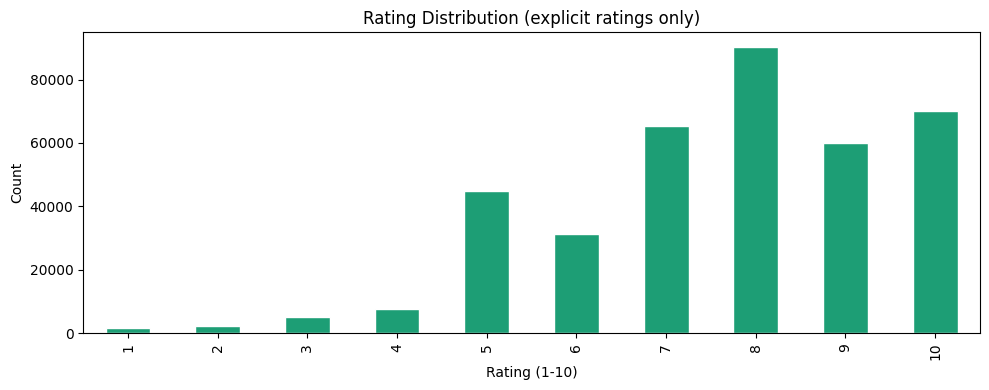

Plot 1 saved: eda_rating_dist.png


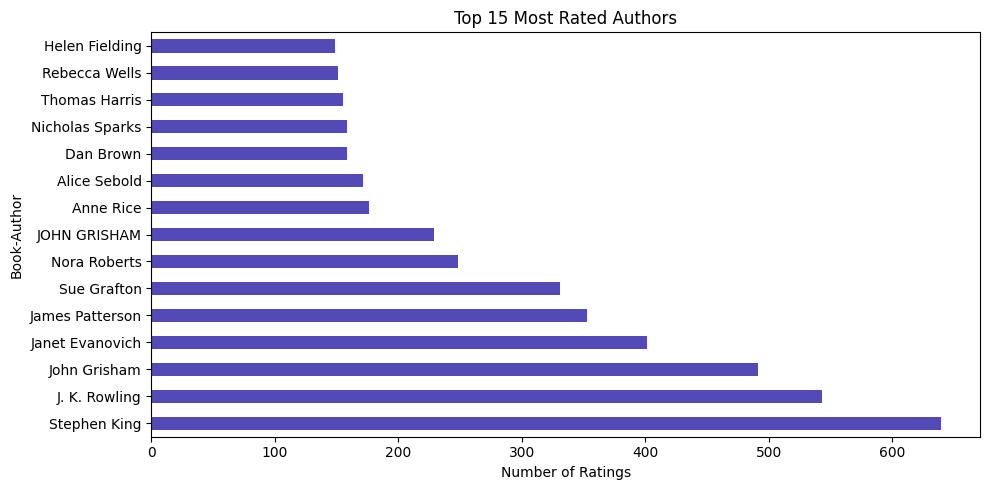

Plot 2 saved: eda_top_authors.png


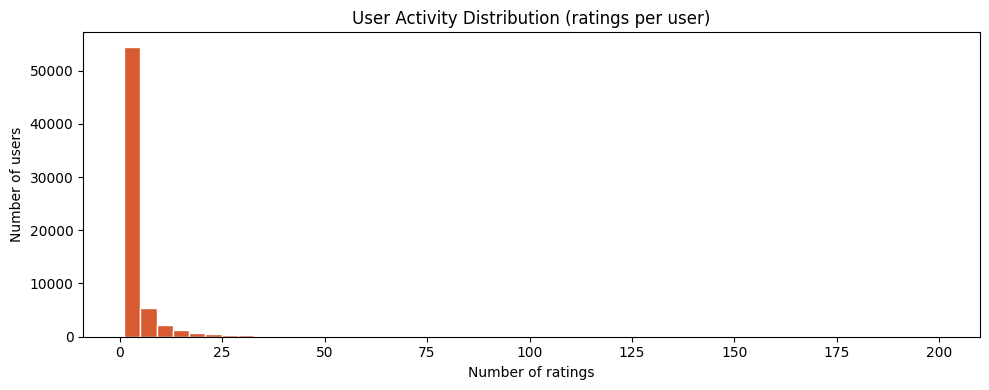

Plot 3 saved: eda_user_activity.png

=== Matrix Stats ===
Unique users    : 1084
Unique books    : 349
Total ratings   : 11149
Sparsity        : 0.9705 (97.1% empty)


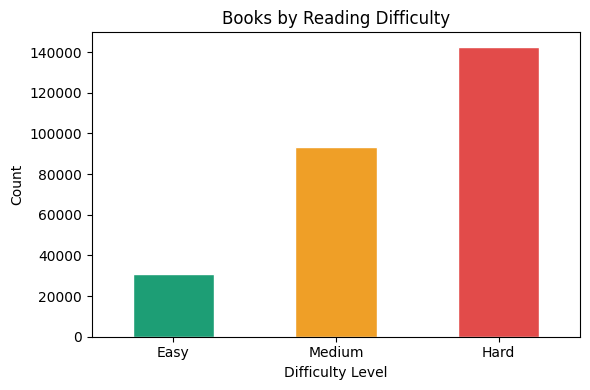

Plot 5 saved: eda_difficulty.png


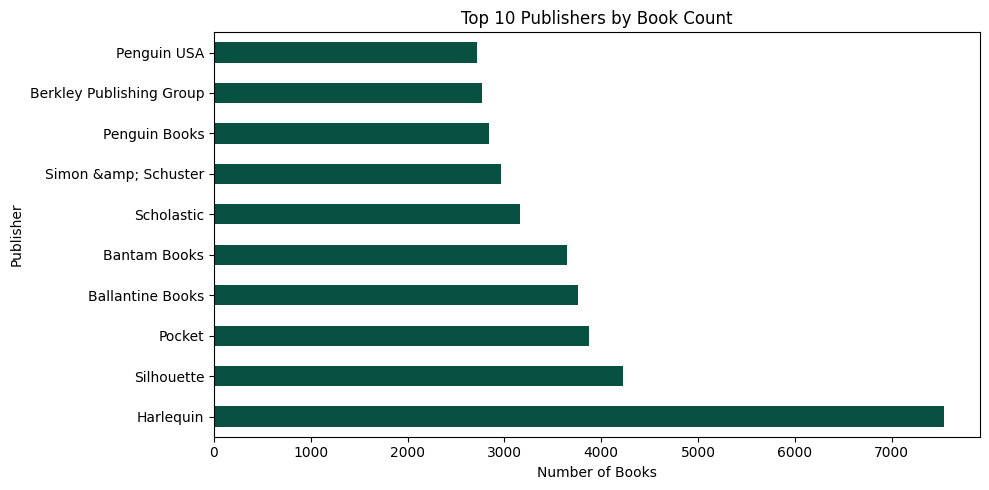

Plot 6 saved: eda_publishers.png


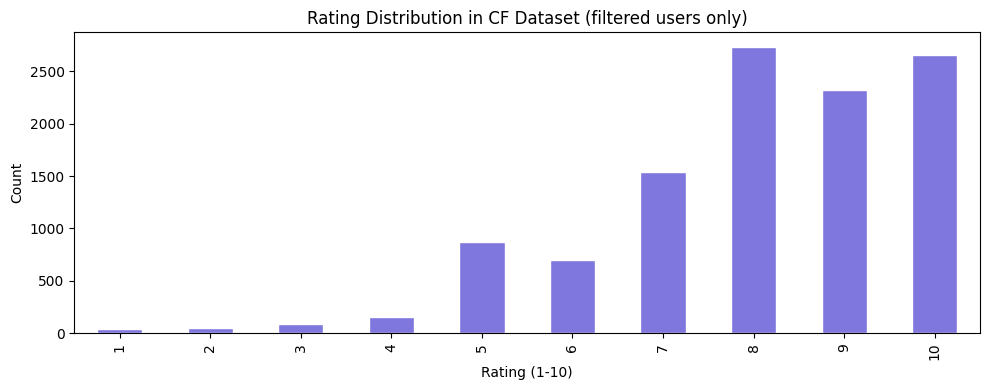

Plot 7 saved: eda_cf_ratings.png

=== Summary Stats ===
Avg rating (all)    : 7.63
Avg rating (CF)     : 8.04
Most common rating  : 8
Rating std dev      : 1.73


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load data ──────────────────────────────────────────────────────
books      = pd.read_csv("data/books_clean.csv")
ratings    = pd.read_csv("data/ratings_clean.csv")
ratings_cf = pd.read_csv("data/ratings_cf.csv")
users      = pd.read_csv("data/users_clean.csv")

print("Dataset loaded successfully")
print(f"books_clean : {books.shape}")
print(f"ratings_cf  : {ratings_cf.shape}")

# ── Plot 1: Rating Distribution ────────────────────────────────────
plt.figure(figsize=(10, 4))
ratings["Book-Rating"].value_counts().sort_index().plot(
    kind="bar", color="#1D9E75", edgecolor="white")
plt.title("Rating Distribution (explicit ratings only)")
plt.xlabel("Rating (1-10)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_rating_dist.png")
plt.show()
print("Plot 1 saved: eda_rating_dist.png")

# ── Plot 2: Top 15 Authors ─────────────────────────────────────────
# Book-Author lives in books_clean.csv — merge it in
if "Book-Author" not in ratings_cf.columns:
    ratings_cf_with_author = ratings_cf.merge(
        books[["ISBN", "Book-Author"]], on="ISBN", how="left")
else:
    ratings_cf_with_author = ratings_cf.copy()

plt.figure(figsize=(10, 5))
top_authors = (ratings_cf_with_author["Book-Author"]
               .value_counts()
               .head(15))
top_authors.plot(kind="barh", color="#534AB7")
plt.title("Top 15 Most Rated Authors")
plt.xlabel("Number of Ratings")
plt.tight_layout()
plt.savefig("eda_top_authors.png")
plt.show()
print("Plot 2 saved: eda_top_authors.png")

# ── Plot 3: User Activity Distribution ────────────────────────────
plt.figure(figsize=(10, 4))
user_activity = ratings["User-ID"].value_counts()
plt.hist(user_activity[user_activity <= 200],
         bins=50, color="#D85A30", edgecolor="white")
plt.title("User Activity Distribution (ratings per user)")
plt.xlabel("Number of ratings")
plt.ylabel("Number of users")
plt.tight_layout()
plt.savefig("eda_user_activity.png")
plt.show()
print("Plot 3 saved: eda_user_activity.png")

# ── Plot 4: Matrix Sparsity Stats ─────────────────────────────────
n_users  = ratings_cf["User-ID"].nunique()
n_books  = ratings_cf["ISBN"].nunique()
total    = n_users * n_books
actual   = len(ratings_cf)
sparsity = 1 - actual / total

print("\n=== Matrix Stats ===")
print(f"Unique users    : {n_users}")
print(f"Unique books    : {n_books}")
print(f"Total ratings   : {actual}")
print(f"Sparsity        : {sparsity:.4f} ({sparsity*100:.1f}% empty)")


# ── Plot 6: Top 10 Publishers ──────────────────────────────────────
plt.figure(figsize=(10, 5))
top_publishers = books["Publisher"].value_counts().head(10)
top_publishers.plot(kind="barh", color="#085041")
plt.title("Top 10 Publishers by Book Count")
plt.xlabel("Number of Books")
plt.tight_layout()
plt.savefig("eda_publishers.png")
plt.show()
print("Plot 6 saved: eda_publishers.png")

# ── Plot 7: Rating Distribution in CF dataset ─────────────────────
plt.figure(figsize=(10, 4))
ratings_cf["Book-Rating"].value_counts().sort_index().plot(
    kind="bar", color="#7F77DD", edgecolor="white")
plt.title("Rating Distribution in CF Dataset (filtered users only)")
plt.xlabel("Rating (1-10)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_cf_ratings.png")
plt.show()
print("Plot 7 saved: eda_cf_ratings.png")

# ── Summary stats ──────────────────────────────────────────────────
print("\n=== Summary Stats ===")
print(f"Avg rating (all)    : {ratings['Book-Rating'].mean():.2f}")
print(f"Avg rating (CF)     : {ratings_cf['Book-Rating'].mean():.2f}")
print(f"Most common rating  : {ratings_cf['Book-Rating'].mode()[0]}")
print(f"Rating std dev      : {ratings_cf['Book-Rating'].std():.2f}")